# Insurance Cost Prediction: EDA and Hypothesis Testing

## Project Overview
Predicting health insurance premiums based on individual health profiles and demographics.

## Dataset
- **Source:** Capstone project dataset
- **Records:** 986
- **Features:** 10 input features + 1 target (PremiumPrice)
- **Missing values:** None

## Notebook Structure
1. Data Loading and First Look
2. Distribution Analysis
3. Feature-wise Analysis
4. Correlation Analysis
5. Outlier Detection
6. Feature Engineering (BMI)
7. Hypothesis Testing

**1. Setup and Imports**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print("Libraries loaded successfully")

Libraries loaded successfully


**2. Data Loading**

In [13]:
# Load the dataset directly from GitHub

df = pd.read_csv('https://raw.githubusercontent.com/pallabiroyds/insurance-cost-prediction/refs/heads/main/data/insurance.csv')

print("Data loaded successfully")


Data loaded successfully


**3. Data Overview**

In [14]:
# Shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

# Column names
print("Columns:", df.columns.tolist())
print()

# Data types and non-null counts
print(df.info())
print()

# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# First 5 rows
df.head()

Rows: 986, Columns: 11

Columns: ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null   

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


**4. Descriptive Statistics**

Summary statistics for all features. Key things to look for:

*   Central tendency (mean versus median) to detect skewness
*   Minimum and maximum ranges to spot potential outliers
*   For binary columns (0/1), the mean represents the proportion with that condition

In [15]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


**5. Distribution Analysis**

**5.1 Target Variable: PremiumPrice**

*   Understanding the distribution of what we're predicting. Looking for skewness, modality, and spread.

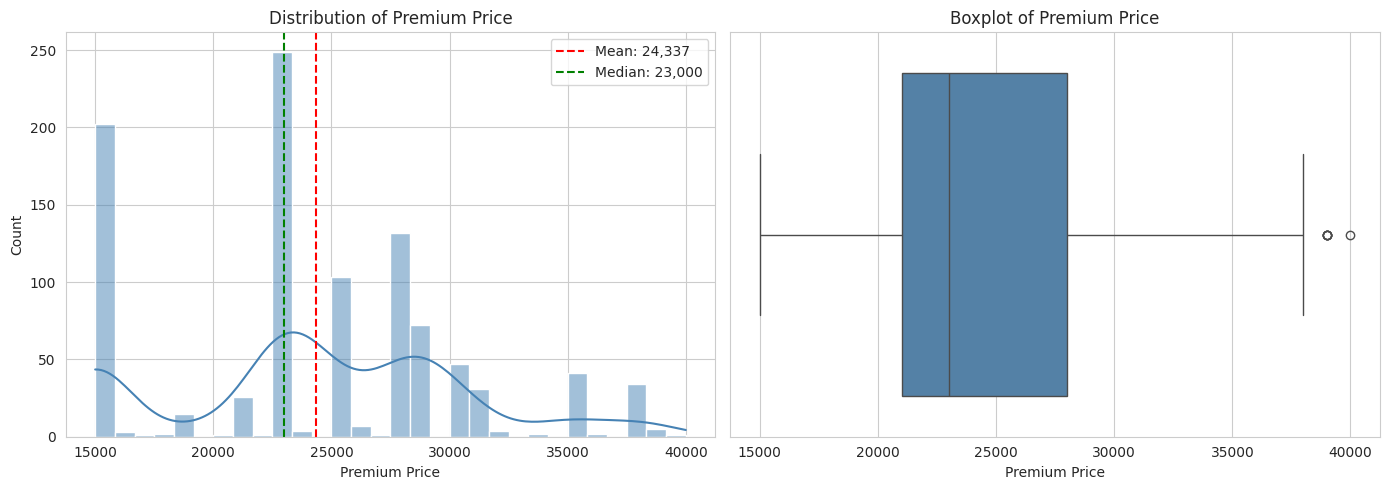

Mean:   24,337
Median: 23,000
Skew:   0.098


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['PremiumPrice'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Premium Price')
axes[0].set_xlabel('Premium Price')
axes[0].set_ylabel('Count')
axes[0].axvline(df['PremiumPrice'].mean(), color='red', linestyle='--', label=f"Mean: {df['PremiumPrice'].mean():,.0f}")
axes[0].axvline(df['PremiumPrice'].median(), color='green', linestyle='--', label=f"Median: {df['PremiumPrice'].median():,.0f}")
axes[0].legend()

# Boxplot
sns.boxplot(x=df['PremiumPrice'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Premium Price')
axes[1].set_xlabel('Premium Price')

plt.tight_layout()
plt.show()

# Print key stats
print(f"Mean:   {df['PremiumPrice'].mean():,.0f}")
print(f"Median: {df['PremiumPrice'].median():,.0f}")
print(f"Skew:   {df['PremiumPrice'].skew():.3f}")